
<b><h2>Pillar 5: Capstone Project</h2></b>

<p>
Submitted by: <b>Darwin A. Nepomuceno</b>
</p>
<p>
<b>Post Graduate Diploma in Artificial Intelligence and Machine Learning</b>
</p>

___


# 🫀 **PHASE 01 | CTG Data — Exploratory Data Analysis**
## **Goal: Understand data quality and distribution  without leakage.**

| Step | What |
|------|------|
| 1 | Initial Inspection — NaN & Duplicates |
| 2 | Target Variable Engineering & Distribution |
| 3 | Feature Analysis — Correlation + Outlier Winsorization |
| 4 | Statistical Testing — ANOVA + Chi-Square |

## 0 · Imports & Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.stats import f_oneway, chi2_contingency

In [2]:
warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"Normal": "#2196F3", "Abnormal": "#F44336"}
FIGSIZE = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


## 1 · Initial Inspection

**What it does :** NaN check → Median/Mode imputation (conditional); duplicate removal with before/after report

In [3]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_excel("../01 data/raw/CTG.xls", sheet_name="Raw Data")

# https://www.kaggle.com/datasets/andrewmvd/fetal-health-classification

# ── Arrow-safe dtype conversion ───────────────────────────────────────────────
# If pandas uses PyArrow as its backend, numeric columns arrive as ArrowDtype
# (e.g. int64[pyarrow], double[pyarrow]) which breaks .quantile() and scipy.
# We convert each column individually, skipping non-numeric ones safely.


def _safe_to_float(col):
    """
    Convert a pandas Series to float64, if possible. If the conversion fails
    (e.g., due to non-numeric values), return the original Series unchanged."""

    try:
        return col.astype("float64")
    except ValueError, TypeError:
        return col  # non-numeric (e.g. string) — leave unchanged


df = pd.concat([_safe_to_float(df[c]) for c in df.columns], axis=1)

print("=" * 55)
print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("  Dtypes after fix:")
print(df.dtypes)
print("=" * 55)
df.head()

  Shape : 2,130 rows × 40 columns
  Dtypes after fix:
FileName               str
Date        datetime64[us]
SegFile                str
b                  float64
e                  float64
LBE                float64
LB                 float64
AC                 float64
FM                 float64
UC                 float64
ASTV               float64
MSTV               float64
ALTV               float64
MLTV               float64
DL                 float64
DS                 float64
DP                 float64
DR                 float64
Width              float64
Min                float64
Max                float64
Nmax               float64
Nzeros             float64
Mode               float64
Mean               float64
Median             float64
Variance           float64
Tendency           float64
A                  float64
B                  float64
C                  float64
D                  float64
E                  float64
AD                 float64
DE                 float64
L

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


### 1a · Verify and reorder columns based on standard UCI list

**What it does :** Select columns based on standard UCI list

In [4]:
standard_cols = [
    "LB",
    "AC",
    "FM",
    "UC",
    "ASTV",
    "MSTV",
    "ALTV",
    "MLTV",
    "DL",
    "DS",
    "DP",
    "Width",
    "Min",
    "Max",
    "Nmax",
    "Nzeros",
    "Mode",
    "Mean",
    "Median",
    "Variance",
    "Tendency",
    "NSP",
]

In [5]:
df = df[standard_cols]
df.T

,0,1,2,3,4,5,6,7,8,9,...,2120,2121,2122,2123,2124,2125,2126,2127,2128,2129
LB,NaN,120.0,132.0,133.0,134.0,132.0,134.0,134.0,122.0,122.0,...,140.0,140.0,140.0,140.0,140.0,140.0,142.0,NaN,NaN,NaN
AC,NaN,0.0,4.0,2.0,2.0,4.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN
FM,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,564.0
UC,NaN,0.0,4.0,5.0,6.0,5.0,10.0,9.0,0.0,1.0,...,6.0,4.0,6.0,9.0,7.0,9.0,5.0,NaN,NaN,23.0
ASTV,NaN,73.0,17.0,16.0,16.0,16.0,26.0,29.0,83.0,84.0,...,79.0,77.0,79.0,78.0,79.0,78.0,74.0,NaN,NaN,87.0
MSTV,NaN,0.5,2.1,2.1,2.4,2.4,5.9,6.3,0.5,0.5,...,0.6,0.7,0.2,0.4,0.4,0.4,0.4,NaN,NaN,7.0
ALTV,NaN,43.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,...,27.0,17.0,25.0,22.0,20.0,27.0,36.0,NaN,NaN,91.0
MLTV,NaN,2.4,10.4,13.4,23.0,19.9,0.0,0.0,15.6,13.6,...,6.4,6.0,7.2,7.1,6.1,7.0,5.0,NaN,NaN,50.7
DL,NaN,0.0,2.0,2.0,2.0,0.0,9.0,6.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,16.0
DS,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0


In [6]:
# df.describe().round(2).T
df.median().round(2).T

LB          133.0
AC            1.0
FM            0.0
UC            3.0
ASTV         49.0
MSTV          1.2
ALTV          0.0
MLTV          7.4
DL            0.0
DS            0.0
DP            0.0
Width        67.5
Min          93.0
Max         162.0
Nmax          3.0
Nzeros        0.0
Mode        139.0
Mean        136.0
Median      139.0
Variance      7.0
Tendency      0.0
NSP           1.0
dtype: float64

In [7]:
dict_median = df.median()
dict_median

LB          133.0
AC            1.0
FM            0.0
UC            3.0
ASTV         49.0
MSTV          1.2
ALTV          0.0
MLTV          7.4
DL            0.0
DS            0.0
DP            0.0
Width        67.5
Min          93.0
Max         162.0
Nmax          3.0
Nzeros        0.0
Mode        139.0
Mean        136.0
Median      139.0
Variance      7.0
Tendency      0.0
NSP           1.0
dtype: float64

### 1b · NaN Check & Imputation

In [8]:
nan_counts = df.isnull().sum()
nan_pct = (nan_counts / len(df) * 100).round(2)
nan_summary = pd.DataFrame({"Missing Count": nan_counts, "Missing %": nan_pct})
nan_summary = nan_summary[nan_summary["Missing Count"] > 0]

if nan_summary.empty:
    print("✅  No missing values found — no imputation required.")
else:
    print(f"⚠️  Missing values in {len(nan_summary)} column(s):")
    print(nan_summary)
    for col in nan_summary.index:
        if pd.api.types.is_numeric_dtype(df[col]):
            fill_val = df[col].median()
            strategy = "Median"
        else:
            fill_val = df[col].mode()[0]
            strategy = "Mode"
        df[col] = df[col].fillna(fill_val)
        print(f"   {col}: filled with {strategy} = {fill_val}")
    print(f"\n✅  Imputation complete. Remaining NaNs: {df.isnull().sum().sum()}")

⚠️  Missing values in 22 column(s):
          Missing Count  Missing %
LB                    4       0.19
AC                    4       0.19
FM                    3       0.14
UC                    3       0.14
ASTV                  3       0.14
MSTV                  3       0.14
ALTV                  3       0.14
MLTV                  3       0.14
DL                    2       0.09
DS                    2       0.09
DP                    2       0.09
Width                 4       0.19
Min                   4       0.19
Max                   4       0.19
Nmax                  4       0.19
Nzeros                4       0.19
Mode                  4       0.19
Mean                  4       0.19
Median                4       0.19
Variance              4       0.19
Tendency              4       0.19
NSP                   4       0.19
   LB: filled with Median = 133.0
   AC: filled with Median = 1.0
   FM: filled with Median = 0.0
   UC: filled with Median = 3.0
   ASTV: filled with Median =

### 1c · Duplicate Removal

In [9]:
n_before = len(df)
n_dupes = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows before  : {n_before:,}")
print(f"Duplicates   : {n_dupes:,}")
print(f"Rows after   : {len(df):,}")
if n_dupes == 0:
    print("\n✅  No duplicates found.")
else:
    print(f"\n⚠️  Removed {n_dupes:,} duplicate row(s).")

Rows before  : 2,130
Duplicates   : 16
Rows after   : 2,114

⚠️  Removed 16 duplicate row(s).


---
## 2 · Target Variable Engineering

**What it does :** Maps NSP 1→0, 2&3→1; bar + pie plots with imbalance ratio printout

In [10]:
print("Original NSP distribution:")
print(df["NSP"].value_counts().sort_index())

# 1 (Normal) → 0 | 2 (Suspect) & 3 (Pathological) → 1 (Abnormal)
df["target"] = df["NSP"].map({1: 0, 2: 1, 3: 1})
df["target_label"] = df["target"].map({0: "Normal", 1: "Abnormal"})

print("\nMapped target distribution:")
print(df["target"].value_counts().sort_index())

Original NSP distribution:
NSP
1.0    1648
2.0     292
3.0     174
Name: count, dtype: int64

Mapped target distribution:
target
0    1648
1     466
Name: count, dtype: int64


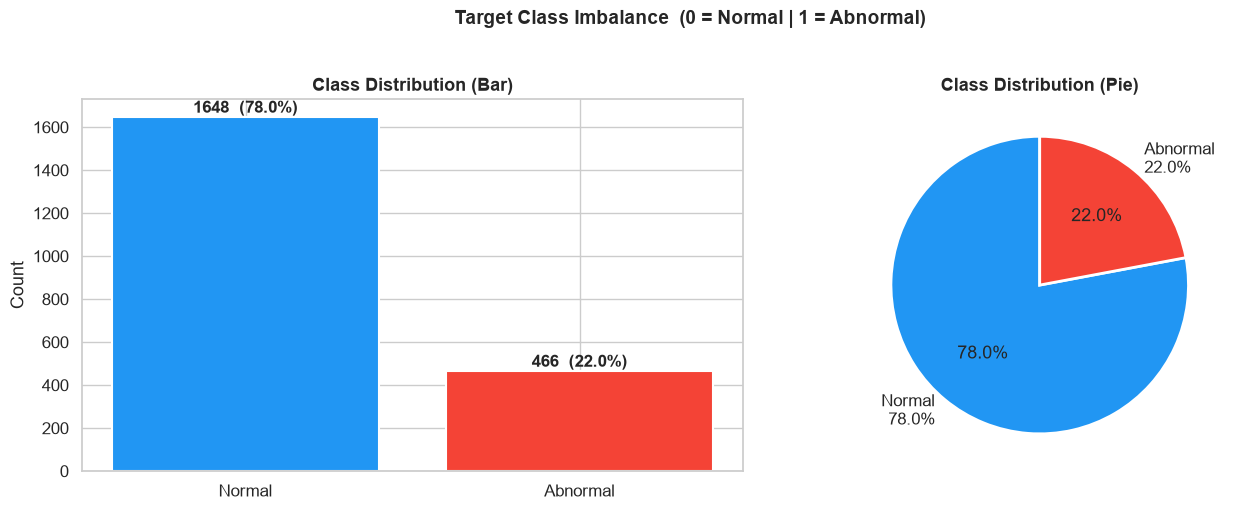


Imbalance Ratio → Normal: 78.0%  |  Abnormal: 22.0%
⚠️  Class imbalance — consider SMOTE / class_weight during modelling.


In [11]:
counts = df["target_label"].value_counts()
pct = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Bar
bars = axes[0].bar(
    counts.index,
    counts.values,
    color=[PALETTE[l] for l in counts.index],
    edgecolor="white",
    linewidth=1.5,
)
for bar, (label, cnt) in zip(bars, counts.items()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{cnt}  ({pct[label]}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12,
    )
axes[0].set_title("Class Distribution (Bar)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Pie
axes[1].pie(
    counts.values,
    labels=[f"{l}\n{pct[l]}%" for l in counts.index],
    colors=[PALETTE[l] for l in counts.index],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.6,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
axes[1].set_title("Class Distribution (Pie)", fontsize=13, fontweight="bold")

plt.suptitle(
    "Target Class Imbalance  (0 = Normal | 1 = Abnormal)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

ratio = pct.get("Normal", 0)
print(f"\nImbalance Ratio → Normal: {ratio}%  |  Abnormal: {100 - ratio}%")
if ratio > 60:
    print("⚠️  Class imbalance — consider SMOTE / class_weight during modelling.")

---
## 3 · Feature Analysis

In [12]:
# Only keep numeric columns — excludes NSP, target, target_label
EXCLUDE = ["NSP", "target", "target_label"]
FEATURES = [
    c for c in df.columns if c not in EXCLUDE and pd.api.types.is_numeric_dtype(df[c])
]
print(f"Feature set ({len(FEATURES)}):")
print(FEATURES)

Feature set (21):
['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']


### 3a · Correlation Matrix

**What it does :** Lower-triangle heatmap; flags 4 high-corr pairs

In [13]:
corr_matrix = df[FEATURES].corr()

HIGH_CORR_THRESH = 0.9
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
    .query("Correlation.abs() > @HIGH_CORR_THRESH")
    .sort_values("Correlation", key=abs, ascending=False)
)

if high_corr_pairs.empty:
    print(f"No pairs with |r| > {HIGH_CORR_THRESH}")
else:
    print(f"High-correlation pairs (|r| > {HIGH_CORR_THRESH}):")
    print(high_corr_pairs.to_string(index=False))
    print(
        "\n📌 Noted but NOT dropped — handle via regularization / VIF / PCA at modelling stage."
    )

High-correlation pairs (|r| > 0.9):
Feature A Feature B  Correlation
     Mean    Median     0.948057
     Mode    Median     0.933148

📌 Noted but NOT dropped — handle via regularization / VIF / PCA at modelling stage.


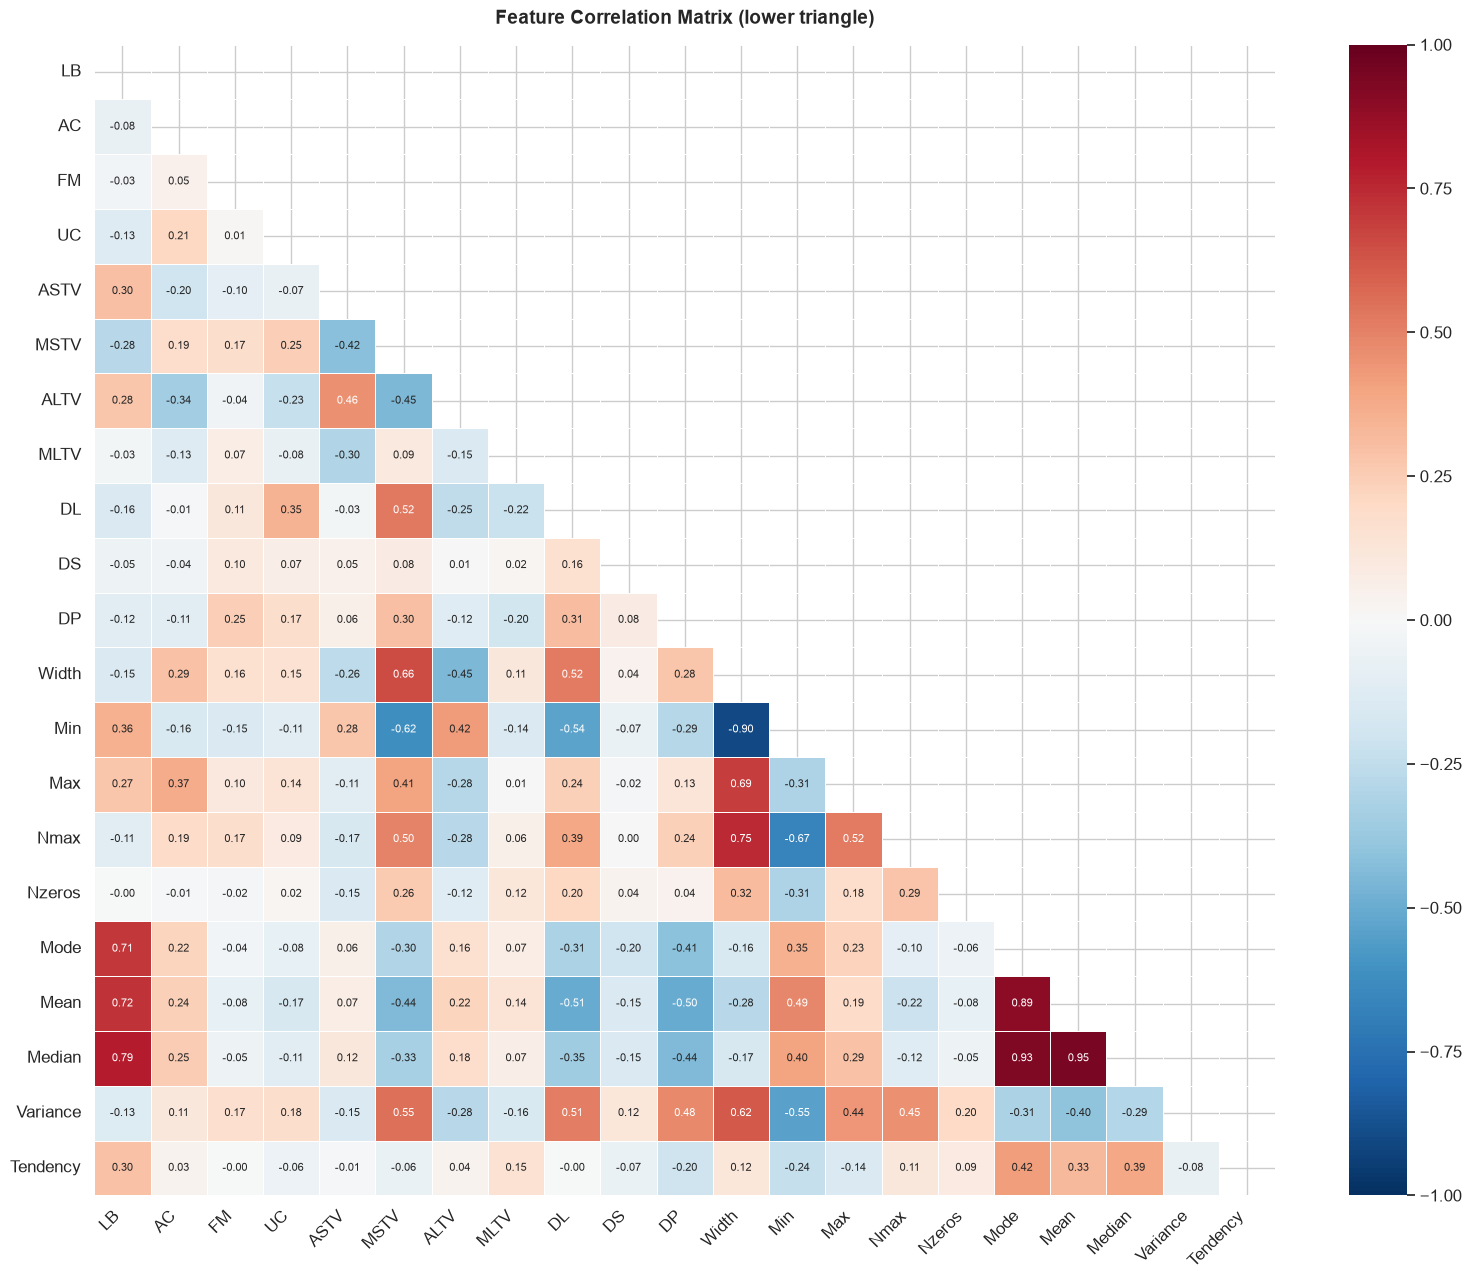

In [14]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title(
    "Feature Correlation Matrix (lower triangle)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3b · Outlier Detection & Winsorization

**What it does :**  Boxplots before & after Winsorization (1st/99th pct + physiological hard limits for each CTG feature); summary table of capped values

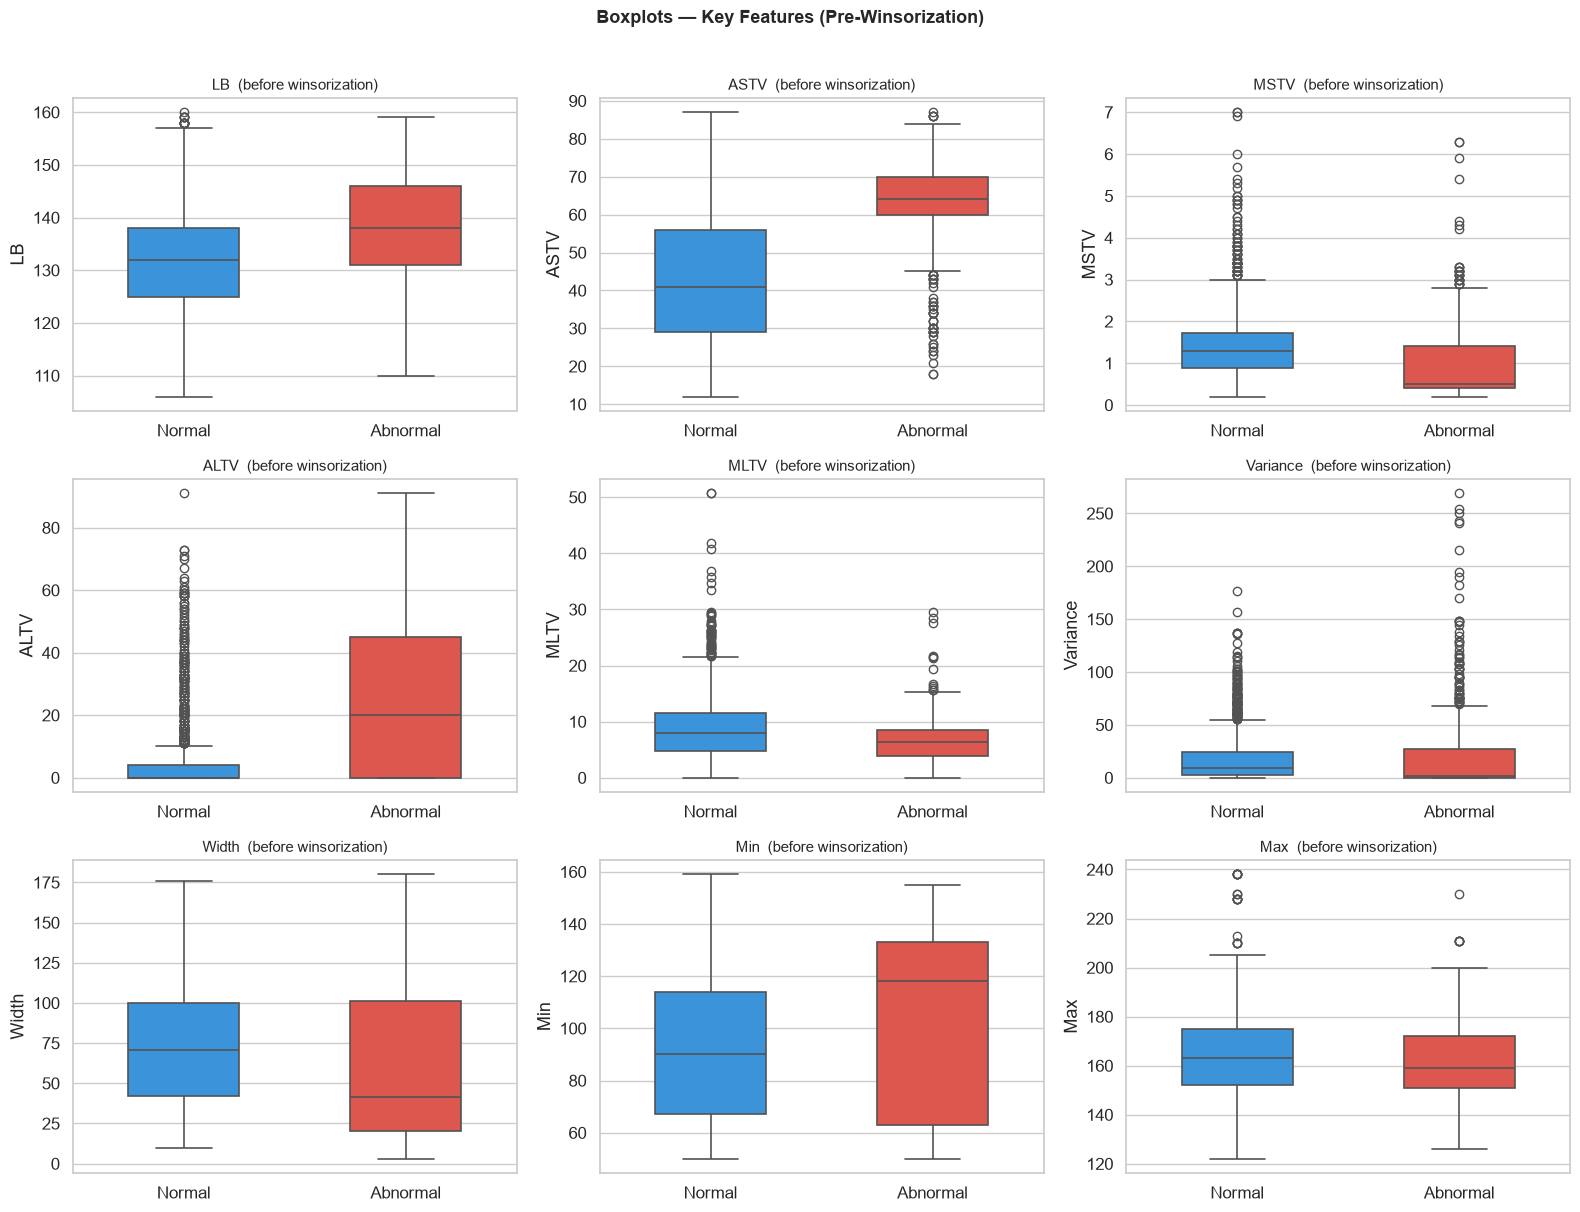

In [15]:
PHYSIO_BOUNDS = {
    "LB": (50, 250),  # Baseline FHR bpm
    "AC": (0, 50),  # Accelerations /s
    "FM": (0, 600),  # Fetal movements /s
    "UC": (0, 50),  # Uterine contractions /s
    "ASTV": (0, 100),  # % time with abnormal STV
    "MSTV": (0, 20),  # Mean STV
    "ALTV": (0, 100),  # % time with abnormal LTV
    "MLTV": (0, 60),  # Mean LTV
    "DL": (0, 100),  # Light decelerations
    "DS": (0, 10),  # Severe decelerations
    "DP": (0, 20),  # Prolonged decelerations
    "Width": (0, 300),  # Histogram width
    "Min": (50, 200),  # Histogram minimum
    "Max": (100, 300),  # Histogram maximum
    "Variance": (0, 1000),  # Histogram variance
}
KEY_FEATURES = ["LB", "ASTV", "MSTV", "ALTV", "MLTV", "Variance", "Width", "Min", "Max"]
n_cols = 3
n_rows = int(np.ceil(len(KEY_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for idx, feat in enumerate(KEY_FEATURES):
    sns.boxplot(
        data=df,
        x="target_label",
        y=feat,
        palette=PALETTE,
        width=0.5,
        linewidth=1.2,
        ax=axes[idx],
    )
    axes[idx].set_title(f"{feat}  (before winsorization)", fontsize=11)
    axes[idx].set_xlabel("")
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(
    "Boxplots — Key Features (Pre-Winsorization)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [16]:
# ── Winsorization: 1st / 99th percentile + physiological hard bounds ─────────
# Uses numpy directly to avoid any pandas/Arrow .quantile() issues.
df_clean = df.copy()
winsorize_report = []

for feat in FEATURES:
    s = df_clean[feat].to_numpy(dtype=float, na_value=np.nan)
    lo_raw = float(np.nanpercentile(s, 1))
    hi_raw = float(np.nanpercentile(s, 99))
    b = PHYSIO_BOUNDS.get(feat)
    lo = max(lo_raw, b[0]) if b else lo_raw
    hi = min(hi_raw, b[1]) if b else hi_raw
    n_cap = int(((s < lo) | (s > hi)).sum())
    df_clean[feat] = np.clip(s, lo, hi)
    winsorize_report.append(
        {
            "Feature": feat,
            "1st pct": round(lo_raw, 3),
            "99th pct": round(hi_raw, 3),
            "Hard Low": b[0] if b else None,
            "Hard High": b[1] if b else None,
            "N capped": n_cap,
        }
    )

df_report = pd.DataFrame(winsorize_report)
print("Winsorization Summary (features with capped values):")
print(df_report[df_report["N capped"] > 0].to_string(index=False))

Winsorization Summary (features with capped values):
 Feature  1st pct  99th pct  Hard Low  Hard High  N capped
      LB   110.00   158.000      50.0      250.0        20
      AC     0.00    14.870       0.0       50.0        22
      FM     0.00   190.400       0.0      600.0        22
      UC     0.00    12.000       0.0       50.0        14
    ASTV    16.00    81.000       0.0      100.0        35
    MSTV     0.20     4.487       0.0       20.0        22
    ALTV     0.00    77.870       0.0      100.0        22
    MLTV     0.00    26.909       0.0       60.0        22
      DL     0.00    10.870       0.0      100.0        22
      DS     0.00     0.000       0.0       10.0         8
      DP     0.00     2.000       0.0       20.0        21
   Width     9.00   150.000       0.0      300.0        37
     Min    50.00   151.000      50.0      200.0        20
     Max   129.00   210.000     100.0      300.0        38
    Nmax     0.00    12.000       NaN        NaN        19
  N

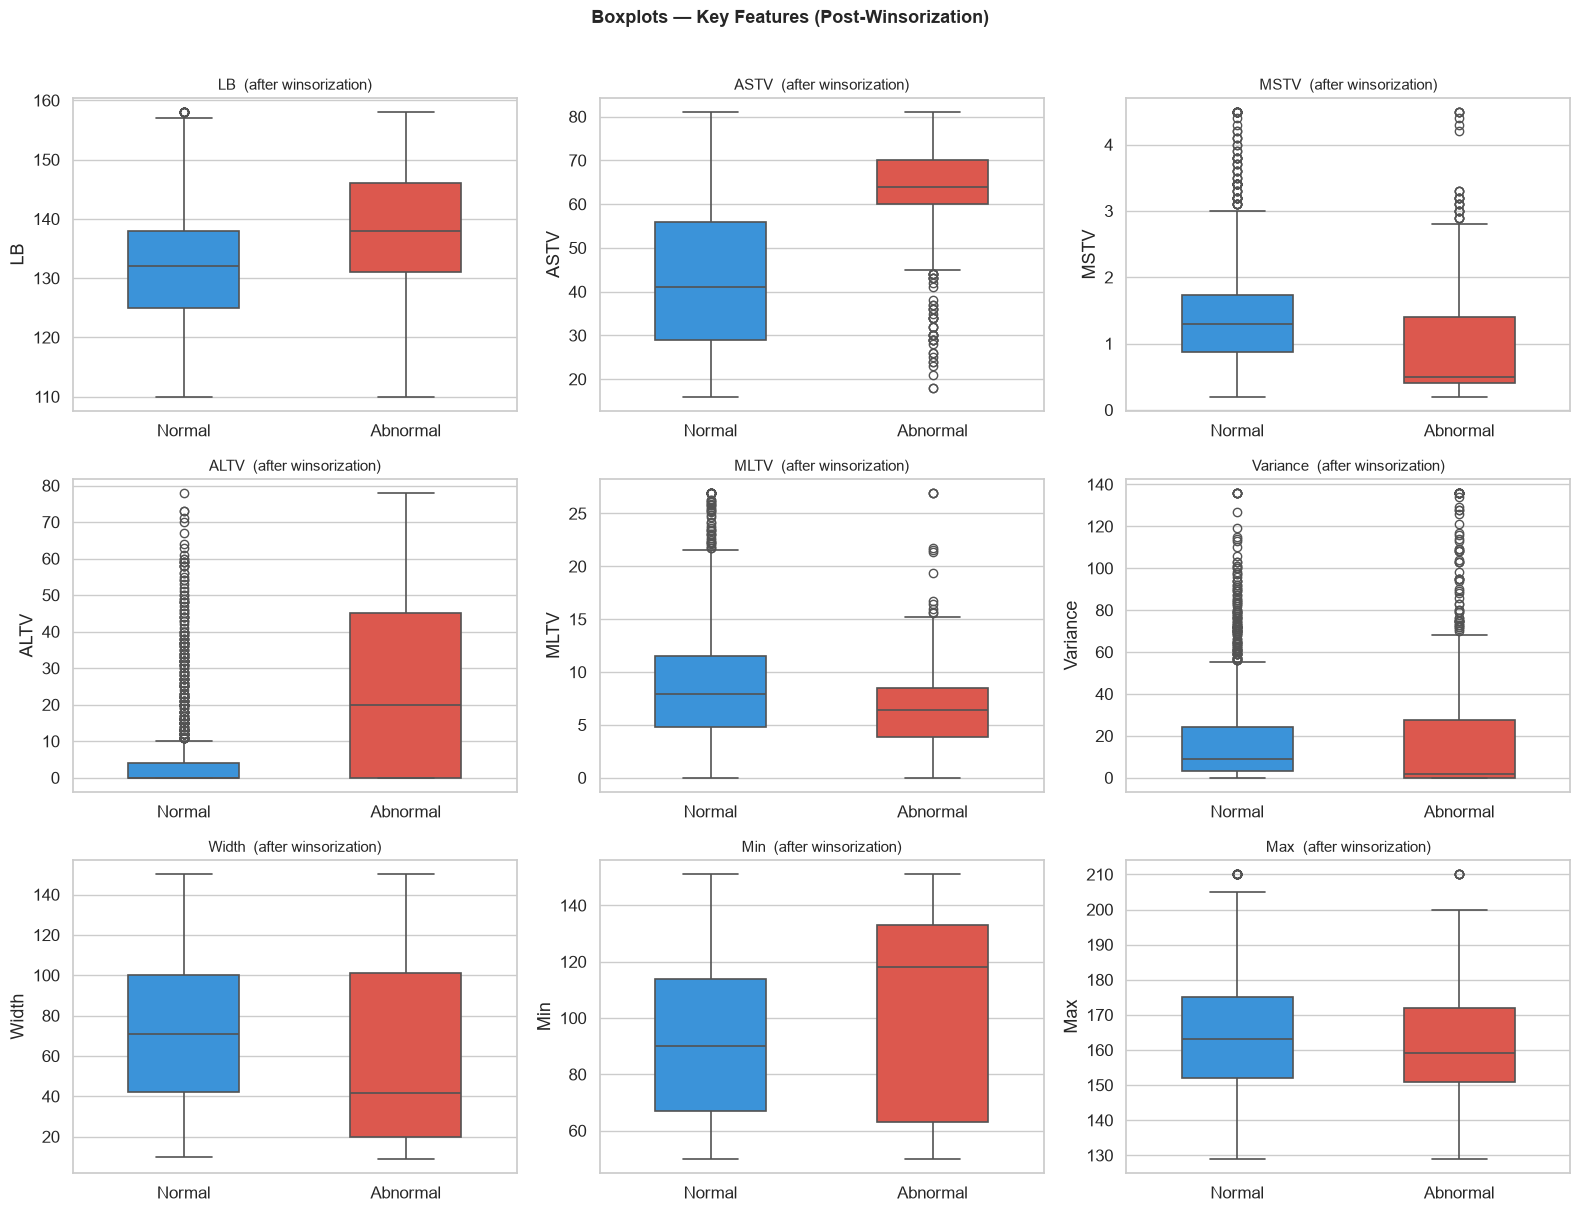

In [17]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for idx, feat in enumerate(KEY_FEATURES):
    sns.boxplot(
        data=df_clean,
        x="target_label",
        y=feat,
        palette=PALETTE,
        width=0.5,
        linewidth=1.2,
        ax=axes[idx],
    )
    axes[idx].set_title(f"{feat}  (after winsorization)", fontsize=11)
    axes[idx].set_xlabel("")
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle(
    "Boxplots — Key Features (Post-Winsorization)",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
## 4 · Statistical Testing

- Continuous features → **ANOVA** (F-test, Normal vs Abnormal)
- Low-cardinality features → **Chi-Square**

Significance threshold: **α = 0.05**

**What it does :** ANOVA for continuous (17 significant), Chi-Square for categorical features (4 significant); combined −log₁₀(p) bar chart

In [18]:
BINARY_LIKE = [f for f in FEATURES if df_clean[f].nunique() <= 10]
CONTINUOUS = [f for f in FEATURES if f not in BINARY_LIKE]
print(f"Continuous  ({len(CONTINUOUS)}) → ANOVA      : {CONTINUOUS}")
print(f"Categorical ({len(BINARY_LIKE)}) → Chi-Square : {BINARY_LIKE}")

Continuous  (17) → ANOVA      : ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'Width', 'Min', 'Max', 'Nmax', 'Mode', 'Mean', 'Median', 'Variance']
Categorical (4) → Chi-Square : ['DS', 'DP', 'Nzeros', 'Tendency']


In [19]:
grp0 = df_clean[df_clean["target"] == 0]
grp1 = df_clean[df_clean["target"] == 1]

anova_results = []
for feat in CONTINUOUS:
    g0 = grp0[feat].dropna()
    g1 = grp1[feat].dropna()
    if len(g0) > 1 and len(g1) > 1:
        f_stat, p_val = f_oneway(g0, g1)
        anova_results.append(
            {
                "Feature": feat,
                "F-Statistic": round(f_stat, 4),
                "p-value": round(p_val, 6),
                "Significant": "✅ Yes" if p_val < 0.05 else "❌ No",
            }
        )

df_anova = pd.DataFrame(anova_results).sort_values("p-value")
print("ANOVA Results (Normal vs Abnormal):")
print(df_anova.to_string(index=False))

ANOVA Results (Normal vs Abnormal):
 Feature  F-Statistic  p-value Significant
      LB     138.7317 0.000000       ✅ Yes
      AC     347.3640 0.000000       ✅ Yes
      UC     109.3157 0.000000       ✅ Yes
    ASTV     661.8411 0.000000       ✅ Yes
    ALTV     636.9332 0.000000       ✅ Yes
    MSTV     104.2208 0.000000       ✅ Yes
    MLTV      65.9059 0.000000       ✅ Yes
   Width      43.4885 0.000000       ✅ Yes
     Min      53.3128 0.000000       ✅ Yes
    Mode      12.6989 0.000374       ✅ Yes
Variance       9.5520 0.002023       ✅ Yes
    Nmax       7.9206 0.004933       ✅ Yes
    Mean       7.2327 0.007215       ✅ Yes
      FM       4.8278 0.028112       ✅ Yes
     Max       4.7068 0.030155       ✅ Yes
  Median       3.3148 0.068801        ❌ No
      DL       2.0179 0.155600        ❌ No


In [20]:
chi2_results = []
for feat in BINARY_LIKE:
    ct = pd.crosstab(df_clean[feat], df_clean["target"])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2_stat, p_val, dof, _ = chi2_contingency(ct)
        chi2_results.append(
            {
                "Feature": feat,
                "Chi2-Statistic": round(chi2_stat, 4),
                "DoF": dof,
                "p-value": round(p_val, 6),
                "Significant": "✅ Yes" if p_val < 0.05 else "❌ No",
            }
        )

df_chi2 = (
    pd.DataFrame(chi2_results).sort_values("p-value")
    if chi2_results
    else pd.DataFrame()
)

if df_chi2.empty:
    print("No categorical features for Chi-Square.")
else:
    print("Chi-Square Results (Normal vs Abnormal):")
    print(df_chi2.to_string(index=False))

Chi-Square Results (Normal vs Abnormal):
 Feature  Chi2-Statistic  DoF  p-value Significant
      DP        266.7281    2 0.000000       ✅ Yes
Tendency         29.2564    2 0.000000       ✅ Yes
  Nzeros          8.6404    3 0.034475       ✅ Yes


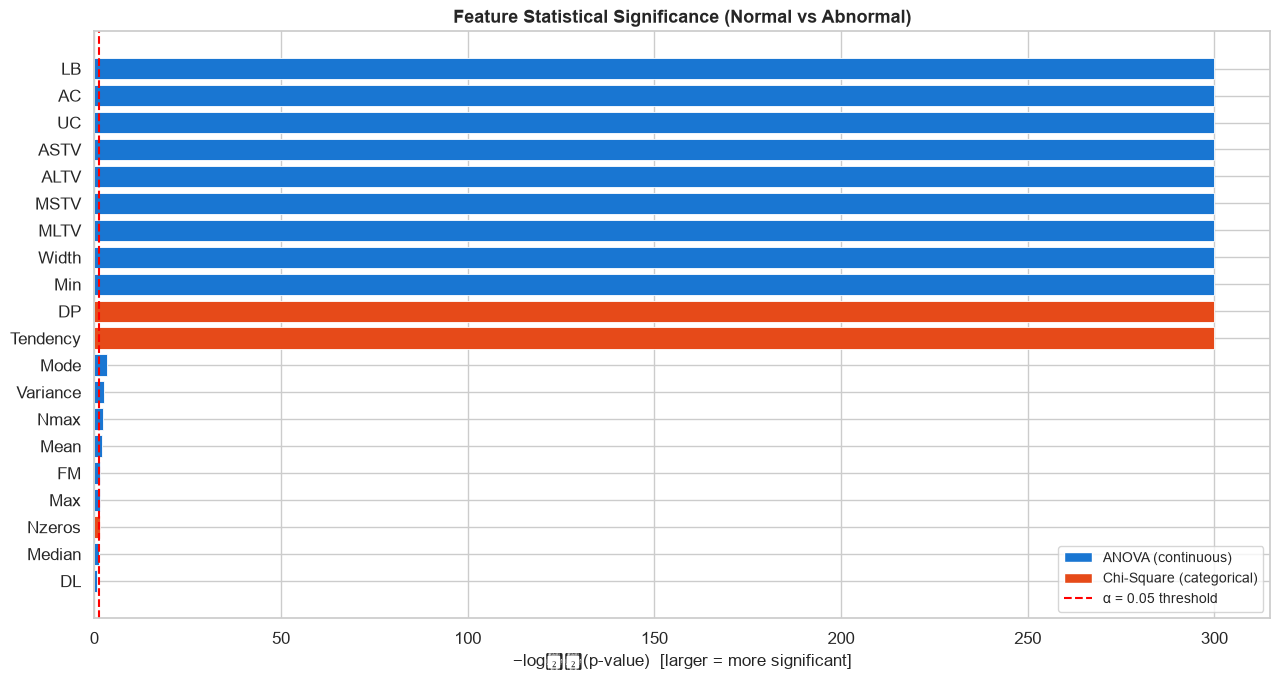

In [21]:
all_results = []
for _, row in df_anova.iterrows():
    all_results.append(
        {"Feature": row["Feature"], "p-value": row["p-value"], "Test": "ANOVA"}
    )
if not df_chi2.empty:
    for _, row in df_chi2.iterrows():
        all_results.append(
            {"Feature": row["Feature"], "p-value": row["p-value"], "Test": "Chi-Square"}
        )

df_stat = pd.DataFrame(all_results).sort_values("p-value")
color_map = {"ANOVA": "#1976D2", "Chi-Square": "#E64A19"}
bar_colors = [color_map[t] for t in df_stat["Test"]]

fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(
    df_stat["Feature"],
    -np.log10(df_stat["p-value"].clip(lower=1e-300)),
    color=bar_colors,
    edgecolor="white",
    linewidth=0.6,
)

sig_line = -np.log10(0.05)
ax.axvline(
    sig_line,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"α = 0.05  (−log₁₀ = {sig_line:.2f})",
)


ax.legend(
    handles=[
        Patch(facecolor="#1976D2", label="ANOVA (continuous)"),
        Patch(facecolor="#E64A19", label="Chi-Square (categorical)"),
        plt.Line2D([0], [0], color="red", linestyle="--", label="α = 0.05 threshold"),
    ],
    loc="lower right",
    fontsize=10,
)

ax.set_xlabel("−log₁₀(p-value)  [larger = more significant]", fontsize=12)
ax.set_title(
    "Feature Statistical Significance (Normal vs Abnormal)",
    fontsize=13,
    fontweight="bold",
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5 · EDA Summary

**What it does :** Printed report with all findings

In [22]:
sig_anova = df_anova[df_anova["Significant"] == "✅ Yes"]["Feature"].tolist()
sig_chi2 = (
    df_chi2[df_chi2["Significant"] == "✅ Yes"]["Feature"].tolist()
    if not df_chi2.empty
    else []
)
insig_feat = [r["Feature"] for r in all_results if r["p-value"] >= 0.05]
normal_pct = round((df_clean["target"] == 0).mean() * 100, 1)

print("=" * 62)
print("  CTG EDA — Summary Report")
print("=" * 62)
print(
    f"  Dataset shape          : {df_clean.shape[0]:,} rows × {len(FEATURES)} features"
)
print(f"  Missing values (final) : {df_clean[FEATURES].isnull().sum().sum()}")
print(f"  Duplicates removed     : {n_dupes}")
print()
print(
    f"  Class balance          : Normal {normal_pct}%  |  Abnormal {100 - normal_pct}%"
)
if high_corr_pairs.empty:
    print("  High-corr pairs (>0.9) : None")
else:
    print(f"  High-corr pairs (>0.9) : {len(high_corr_pairs)} — noted, NOT dropped")
    for _, row in high_corr_pairs.iterrows():
        print(
            f"    • {row['Feature A']} ↔ {row['Feature B']} : r = {row['Correlation']:.3f}"
        )
print()
print(f"  Significant (ANOVA)      : {sig_anova}")
print(f"  Significant (Chi-Square) : {sig_chi2}")
print(f"  Not significant (p≥0.05) : {insig_feat}")

print("=" * 62)

  CTG EDA — Summary Report
  Dataset shape          : 2,114 rows × 21 features
  Missing values (final) : 0
  Duplicates removed     : 16

  Class balance          : Normal 78.0%  |  Abnormal 22.0%
  High-corr pairs (>0.9) : 2 — noted, NOT dropped
    • Mean ↔ Median : r = 0.948
    • Mode ↔ Median : r = 0.933

  Significant (ANOVA)      : ['LB', 'AC', 'UC', 'ASTV', 'ALTV', 'MSTV', 'MLTV', 'Width', 'Min', 'Mode', 'Variance', 'Nmax', 'Mean', 'FM', 'Max']
  Significant (Chi-Square) : ['DP', 'Tendency', 'Nzeros']
  Not significant (p≥0.05) : ['Median', 'DL']


---
## 6 · Saving Data

**What it does :** Saving cleaned data

In [23]:
df.to_excel("../01 data/clean/CTG_cleaned.xlsx", index=False)
print("\n✅ Cleaned data saved to '../01 data/clean/CTG_cleaned.xls' ")


✅ Cleaned data saved to '../01 data/clean/CTG_cleaned.xls' 


---
## References

**Dataset**
- Campos, D. & Bernardes, J. (2000). *Cardiotocography* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.10432/C51S4N
- UCI ML Repository — Cardiotocography: https://archive.ics.uci.edu/dataset/193/cardiotocography

**Clinical Background (CTG Interpretation)**
- Ayres-de-Campos, D. et al. (2015). *FIGO consensus guidelines on intrapartum fetal monitoring: Cardiotocography*. Int J Gynecol Obstet, 131(1), 13–24. https://doi.org/10.1016/j.ijgo.2015.06.020
- FIGO official guideline portal: https://www.figo.org/news/available-view-figo-intrapartum-fetal-monitoring-guidelines

**Statistical Methods**
- SciPy `f_oneway` (ANOVA) documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
- SciPy `chi2_contingency` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html

**Outlier Handling**
- NIST/SEMATECH — *Winsorized Mean* (Dataplot Reference Manual): https://www.itl.nist.gov/div898/software/dataplot/refman2/ch2/winsmean.pdf
- Dixon, W.J. (1960). *Simplified Estimation from Censored Normal Samples*. Annals of Mathematical Statistics, 31(2), 385-391. https://doi.org/10.1214/aoms/1177705900 (foundational paper on Winsorized estimation)
